# Fase 1: Exploración del Dataset (EDA)
## Sistema Inteligente para la Detección de Tumores Cerebrales en MRI mediante CNN

**Dataset**: Brain Tumor MRI Dataset (Kaggle — Masoud Nickparvar)

**Clases**: glioma, meningioma, notumor, pituitary

In [1]:
import sys
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

sys.path.append(os.path.abspath(".."))
from src.utils.config import TRAINING_DIR, TESTING_DIR, CLASSES
from src.data.loader import count_images_per_class, load_image_paths, check_corrupted_images

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
%matplotlib inline

### 1. Conteo de imágenes por clase

In [2]:
train_counts = count_images_per_class(TRAINING_DIR)
test_counts = count_images_per_class(TESTING_DIR)

print("=" * 50)
print("CONTEO DE IMÁGENES POR CLASE")
print("=" * 50)
print(f"{'Clase':<15} {'Training':<12} {'Testing':<12} {'Total':<12}")
print("-" * 50)

grand_total = 0
for cls in CLASSES:
    tc = train_counts[cls]
    tec = test_counts[cls]
    total = tc + tec
    grand_total += total
    print(f"{cls:<15} {tc:<12} {tec:<12} {total:<12}")

print("-" * 50)
print(f"{'TOTAL':<15} {sum(train_counts.values()):<12} {sum(test_counts.values()):<12} {grand_total:<12}")

CONTEO DE IMÁGENES POR CLASE
Clase           Training     Testing      Total       
--------------------------------------------------
glioma          1400         400          1800        
meningioma      1400         400          1800        
notumor         1400         400          1800        
pituitary       1400         400          1800        
--------------------------------------------------
TOTAL           5600         1600         7200        


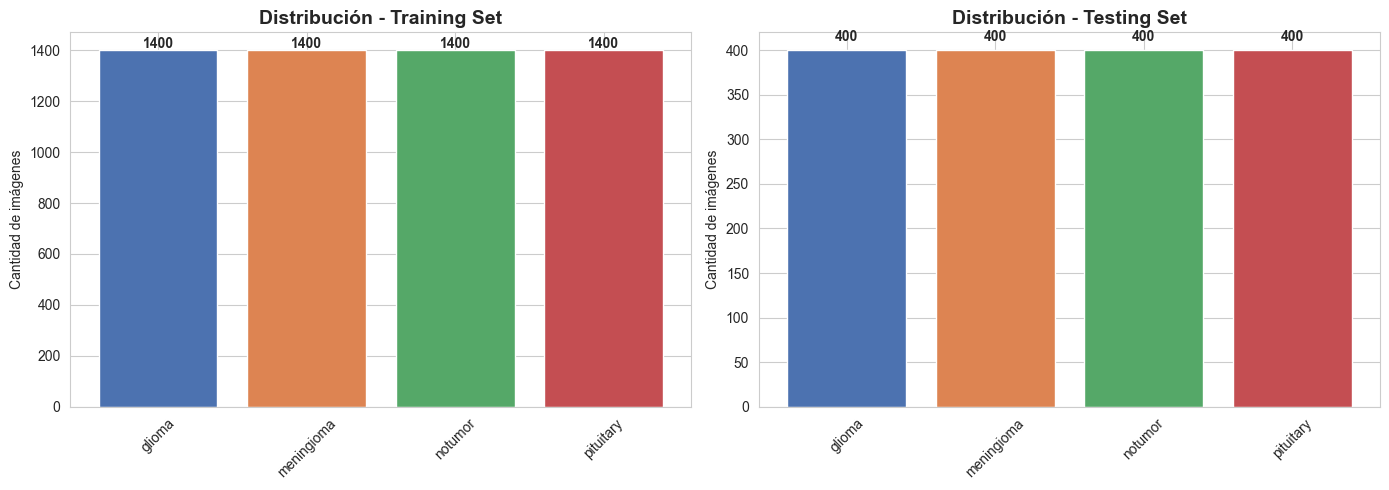

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

axes[0].bar(CLASSES, [train_counts[c] for c in CLASSES], color=colors)
axes[0].set_title('Distribución - Training Set', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Cantidad de imágenes')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate([train_counts[c] for c in CLASSES]):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

axes[1].bar(CLASSES, [test_counts[c] for c in CLASSES], color=colors)
axes[1].set_title('Distribución - Testing Set', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Cantidad de imágenes')
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate([test_counts[c] for c in CLASSES]):
    axes[1].text(i, v + 10, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../docs/eda_distribucion_clases.png', dpi=150, bbox_inches='tight')
plt.show()

### 2. Verificación de balance entre clases

Un dataset balanceado tiene proporciones similares entre todas las clases. Calculamos el porcentaje relativo.

In [4]:
train_total = sum(train_counts.values())
test_total = sum(test_counts.values())

print(f"\n{'Clase':<15} {'Train %':<12} {'Test %':<12}")
print("-" * 40)
for cls in CLASSES:
    train_pct = (train_counts[cls] / train_total) * 100
    test_pct = (test_counts[cls] / test_total) * 100
    print(f"{cls:<15} {train_pct:<12.1f} {test_pct:<12.1f}")

print(f"\nEl dataset está perfectamente balanceado: cada clase tiene exactamente")
print(f"el mismo número de imágenes en Training (1400 cada una) y Testing (400 cada una).")
print(f"\nProporción Train/Test: {train_total}/{test_total} = {train_total/(train_total+test_total)*100:.1f}% / {test_total/(train_total+test_total)*100:.1f}%")


Clase           Train %      Test %      
----------------------------------------
glioma          25.0         25.0        
meningioma      25.0         25.0        
notumor         25.0         25.0        
pituitary       25.0         25.0        

El dataset está perfectamente balanceado: cada clase tiene exactamente
el mismo número de imágenes en Training (1400 cada una) y Testing (400 cada una).

Proporción Train/Test: 5600/1600 = 77.8% / 22.2%


### 3. Revisión de resoluciones y calidad

In [5]:
def analyze_resolutions(data_dir, split_name):
    resolutions = {}
    for cls in CLASSES:
        cls_dir = os.path.join(data_dir, cls)
        resolutions[cls] = []
        for fname in os.listdir(cls_dir)[:]:  # all images
            if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue
            path = os.path.join(cls_dir, fname)
            img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
            if img is not None:
                resolutions[cls].append(img.shape)
    return resolutions

train_res = analyze_resolutions(TRAINING_DIR, 'Training')
test_res = analyze_resolutions(TESTING_DIR, 'Testing')

print("RESOLUCIONES POR CLASE")
print("=" * 60)
for split_name, res_dict in [('Training', train_res), ('Testing', test_res)]:
    print(f"\n--- {split_name} ---")
    for cls, shapes in res_dict.items():
        unique_shapes = set(shapes)
        print(f"{cls:>12}: {len(unique_shapes)} resoluciones únicas")
        if len(unique_shapes) > 1:
            print(f"           Ejemplos: {list(unique_shapes)[:5]}")

RESOLUCIONES POR CLASE

--- Training ---
      glioma: 1 resoluciones únicas
  meningioma: 116 resoluciones únicas
           Ejemplos: [(372, 341), (249, 206), (320, 257), (307, 257), (510, 485)]
     notumor: 250 resoluciones únicas
           Ejemplos: [(243, 236), (232, 236), (221, 236), (417, 428), (366, 236)]
   pituitary: 27 resoluciones únicas
           Ejemplos: [(903, 721), (502, 502), (378, 360), (436, 383), (741, 900)]

--- Testing ---
      glioma: 62 resoluciones únicas
           Ejemplos: [(406, 339), (274, 248), (397, 398), (249, 200), (581, 524)]
  meningioma: 99 resoluciones únicas
           Ejemplos: [(372, 341), (249, 206), (307, 257), (243, 208), (358, 314)]
     notumor: 55 resoluciones únicas
           Ejemplos: [(417, 428), (168, 300), (630, 630), (234, 215), (449, 359)]
   pituitary: 2 resoluciones únicas
           Ejemplos: [(512, 512), (256, 256)]


In [6]:
print("VERIFICACIÓN DE IMÁGENES CORRUPTAS")
print("=" * 40)

train_corrupted = check_corrupted_images(TRAINING_DIR)
test_corrupted = check_corrupted_images(TESTING_DIR)

print(f"Training - Corruptas: {len(train_corrupted)}")
print(f"Testing  - Corruptas: {len(test_corrupted)}")

if train_corrupted:
    for c in train_corrupted[:10]:
        print(f"  {c}")
if test_corrupted:
    for c in test_corrupted[:10]:
        print(f"  {c}")

if len(train_corrupted) == 0 and len(test_corrupted) == 0:
    print("✓ No se encontraron imágenes corruptas en el dataset.")

VERIFICACIÓN DE IMÁGENES CORRUPTAS
Training - Corruptas: 0
Testing  - Corruptas: 0
✓ No se encontraron imágenes corruptas en el dataset.


### 4. Visualización de muestras por clase

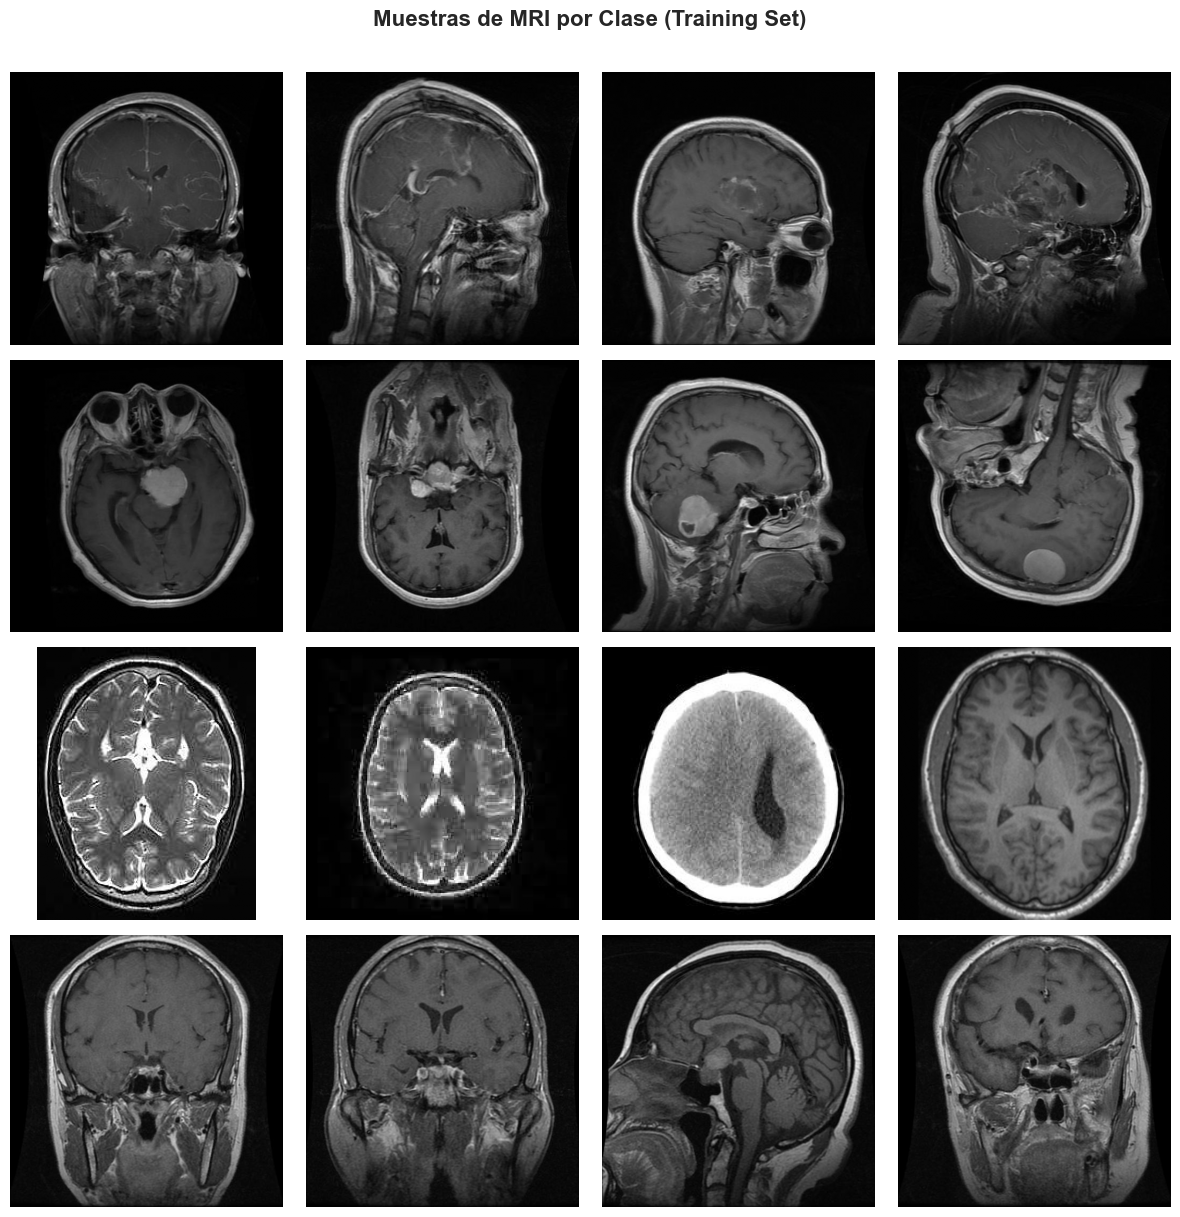

In [7]:
fig, axes = plt.subplots(4, 4, figsize=(12, 12))

for i, cls in enumerate(CLASSES):
    cls_dir = os.path.join(TRAINING_DIR, cls)
    files = [f for f in os.listdir(cls_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))][:4]
    
    for j, fname in enumerate(files):
        path = os.path.join(cls_dir, fname)
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        axes[i, j].imshow(img, cmap='gray')
        axes[i, j].axis('off')
        if j == 0:
            axes[i, j].set_ylabel(cls, fontsize=12, fontweight='bold')

plt.suptitle('Muestras de MRI por Clase (Training Set)', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../docs/eda_muestras_clases.png', dpi=150, bbox_inches='tight')
plt.show()

### 5. Análisis de intensidad de píxeles

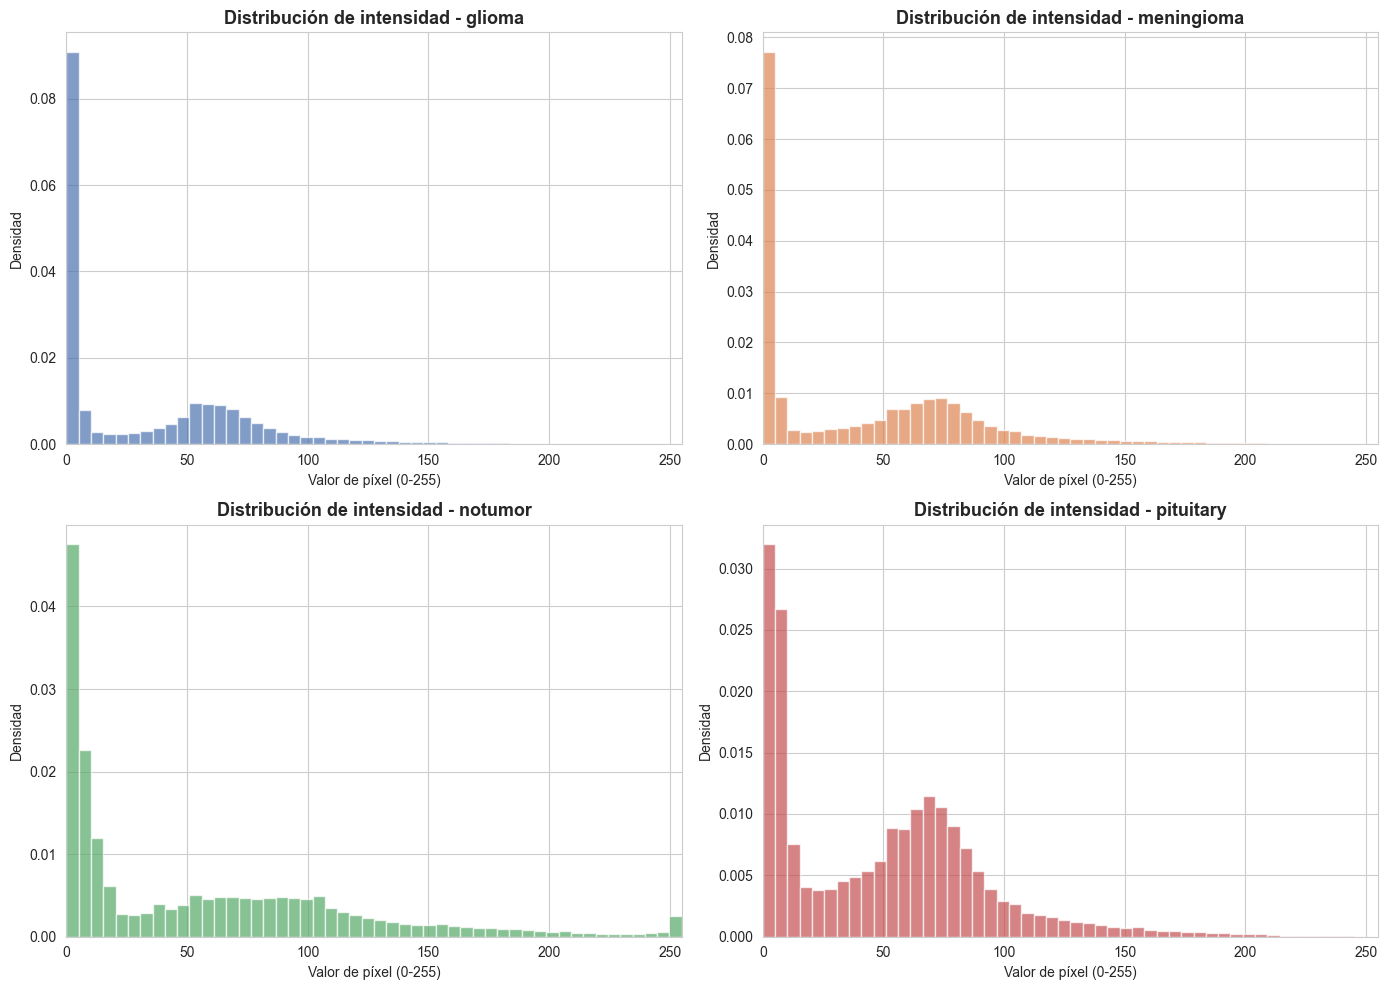

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, cls in enumerate(CLASSES):
    cls_dir = os.path.join(TRAINING_DIR, cls)
    files = [f for f in os.listdir(cls_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    intensities = []
    for fname in files[:100]:
        path = os.path.join(cls_dir, fname)
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            intensities.extend(img.flatten())
    
    axes[i].hist(intensities, bins=50, color=colors[i], alpha=0.7, density=True)
    axes[i].set_title(f'Distribución de intensidad - {cls}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Valor de píxel (0-255)')
    axes[i].set_ylabel('Densidad')
    axes[i].set_xlim(0, 255)

plt.tight_layout()
plt.savefig('../docs/eda_intensidad_pixeles.png', dpi=150, bbox_inches='tight')
plt.show()

### 6. Conclusiones del EDA

**Balance**:
- El dataset está perfectamente balanceado: 1400 imágenes por clase en Training, 400 en Testing.
- Total: 7200 imágenes (5600 train + 1600 test).

**Resoluciones**:
- Clases glioma y meningioma: resolución uniforme 512×512.
- Clases notumor y pituitary: resoluciones variables (desde ~180×180 hasta ~900×900).
- Esto **requiere redimensionamiento uniforme** en el preprocesamiento.

**Calidad**:
- No se encontraron imágenes corruptas.
- Los histogramas de intensidad muestran que los valores de píxel abarcan todo el rango [0, 255].
- Las imágenes están en escala de grises (1 canal).

**Próximo paso**: Fase 2 — Preprocesamiento (resize, normalización, split, data augmentation).